# Regression Models with PySpark (Linear Regression & XGBoost)

This notebook builds regression models to predict **resolution time** (time to resolve complaints) using the Traffy Fondue dataset.

**Target Variable:** `resolution_time` = `last_activity` - `timestamp` (in hours)


## 1. Setup & Import Libraries

In [1]:
# Install dependencies if needed
!pip install pyspark xgboost tqdm

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, lit, unix_timestamp, isnan, isnull, date_trunc, avg
from pyspark.sql.types import DoubleType
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.regression import LinearRegression

# XGBoost
from xgboost.spark import SparkXGBRegressor

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Initialize Spark Session
spark = SparkSession.builder \
    .appName("Resolution_Time_Prediction") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.sql.legacy.timeParserPolicy", "LEGACY") \
    .getOrCreate()

print(f"Spark version: {spark.version}")
spark

Spark version: 3.5.0


## 2. Load and Explore Data

In [3]:
# Load the merged dataset
data_path = "../../data/processed/bangkok_traffy_merged.csv"

# เพิ่ม option("multiLine", "true") และ option("escape", "\"")
df_spark = spark.read.option("multiLine", "true").option("escape", "\"").csv(data_path, header=True, inferSchema=True)

print(f"Dataset shape: {df_spark.count()} rows, {len(df_spark.columns)} columns")
df_spark.printSchema()

Dataset shape: 209265 rows, 31 columns
root
 |-- ticket_id: string (nullable = true)
 |-- type: string (nullable = true)
 |-- organization: string (nullable = true)
 |-- comment: string (nullable = true)
 |-- photo: string (nullable = true)
 |-- photo_after: string (nullable = true)
 |-- coords: string (nullable = true)
 |-- address: string (nullable = true)
 |-- subdistrict: string (nullable = true)
 |-- district: string (nullable = true)
 |-- province: string (nullable = true)
 |-- timestamp: string (nullable = true)
 |-- state: string (nullable = true)
 |-- count_reopen: integer (nullable = true)
 |-- last_activity: string (nullable = true)
 |-- type_clean: string (nullable = true)
 |-- has_photo: boolean (nullable = true)
 |-- comment_len: integer (nullable = true)
 |-- lon: double (nullable = true)
 |-- lat: double (nullable = true)
 |-- date: string (nullable = true)
 |-- pm25_avg: double (nullable = true)
 |-- pm25_max: double (nullable = true)
 |-- pm25_min: double (nullable = 

In [4]:
# Preview data
df_spark.show(5, truncate=True)

+-----------+-----------------+--------------------+--------------------+--------------------+--------------------+------------------+--------------------+-----------+---------+-------------+--------------------+---------+------------+--------------------+---------------+---------+-----------+---------+--------+----------+------------------+--------+--------+------------------+------------------+-----------+--------------+--------+----------+----------+
|  ticket_id|             type|        organization|             comment|               photo|         photo_after|            coords|             address|subdistrict| district|     province|           timestamp|    state|count_reopen|       last_activity|     type_clean|has_photo|comment_len|      lon|     lat|      date|          pm25_avg|pm25_max|pm25_min|          pm10_avg|          dust_avg|rainfall_mm|rainfall_hours|has_rain|heavy_rain|dept_count|
+-----------+-----------------+--------------------+--------------------+-----------

## 3. Feature Engineering - Create Target Variable

In [5]:
# Create resolution_time (in hours)
# resolution_time = last_activity - timestamp

# Use cast("timestamp") to handle ISO8601 format with timezone (e.g., 2022-06-21 08:21:09.532782+00)
df_spark = df_spark.withColumn("last_activity_ts", col("last_activity").cast("timestamp"))
df_spark = df_spark.withColumn("timestamp_ts", col("timestamp").cast("timestamp"))

df_spark = df_spark.withColumn(
    "resolution_time",
    (col("last_activity_ts").cast("long") - col("timestamp_ts").cast("long")) / 3600.0
)

# Filter out negative or unreasonable values
df_spark = df_spark.filter(
    (col("resolution_time") > 0) & 
    (col("resolution_time") < 8760)  # Less than 1 year
)

print(f"After initial filtering: {df_spark.count()} rows")

# --- Filter Top/Bottom 10% ---
# Calculate 10th and 90th percentiles
quantiles = df_spark.approxQuantile("resolution_time", [0.1, 0.9], 0.01)
lower_bound = quantiles[0]
upper_bound = quantiles[1]

print(f"Filtering data between 10th percentile ({lower_bound:.2f} hours) and 90th percentile ({upper_bound:.2f} hours)")

df_spark = df_spark.filter(
    (col("resolution_time") >= lower_bound) & 
    (col("resolution_time") <= upper_bound)
)

print(f"After percentile filtering: {df_spark.count()} rows")

# Show resolution time statistics
df_spark.select("resolution_time").describe().show()

After initial filtering: 200656 rows
Filtering data between 10th percentile (14.12 hours) and 90th percentile (3312.58 hours)
After percentile filtering: 160776 rows
+-------+------------------+
|summary|   resolution_time|
+-------+------------------+
|  count|            160776|
|   mean|474.95267259347344|
| stddev| 714.5994043908981|
|    min| 14.12138888888889|
|    max| 3312.583611111111|
+-------+------------------+



## 4. Data Preprocessing

Calculating resolution time distribution...


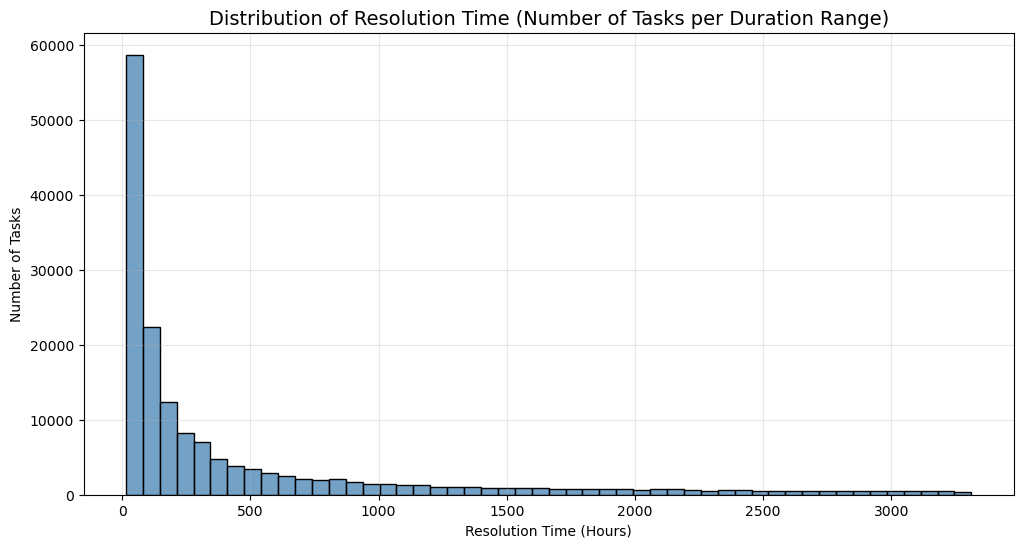

Histogram displayed.


In [6]:
# --- Visualization: Distribution of Resolution Time ---
print("Calculating resolution time distribution...")

# Convert resolution_time to Pandas for plotting
resolution_times = df_spark.select("resolution_time").toPandas()

plt.figure(figsize=(12, 6))
# Histogram to show count of tasks per resolution time range
sns.histplot(resolution_times['resolution_time'], bins=50, kde=False, color='steelblue', edgecolor='black')
plt.title('Distribution of Resolution Time (Number of Tasks per Duration Range)', fontsize=14)
plt.xlabel('Resolution Time (Hours)')
plt.ylabel('Number of Tasks')
plt.grid(True, alpha=0.3)
plt.show()

print("Histogram displayed.")

In [7]:
# Select features for modeling
feature_cols = [
       'coords','timestamp',
       'state', 'count_reopen', 'last_activity', 
       'comment_len', 'lon', 'lat','pm25_avg',
       'pm10_avg', 'dust_avg', 'rainfall_mm', 'has_rain', 'dept_count']

categorical_cols = ['organization',"type_clean", "district"]

# Select and Cast numeric features to DoubleType explicitly
# This ensures all numeric columns are actually doubles, preventing StringType errors
selected_cols = [col(c).cast("double").alias(c) for c in feature_cols] + \
                [col(c) for c in categorical_cols] + \
                [col("resolution_time")]

df_model = df_spark.select(selected_cols)

print(f"Selected {len(feature_cols)} numeric features and {len(categorical_cols)} categorical features")
print("Schema after casting:")
df_model.printSchema()

Selected 14 numeric features and 3 categorical features
Schema after casting:
root
 |-- coords: double (nullable = true)
 |-- timestamp: double (nullable = true)
 |-- state: double (nullable = true)
 |-- count_reopen: double (nullable = true)
 |-- last_activity: double (nullable = true)
 |-- comment_len: double (nullable = true)
 |-- lon: double (nullable = true)
 |-- lat: double (nullable = true)
 |-- pm25_avg: double (nullable = true)
 |-- pm10_avg: double (nullable = true)
 |-- dust_avg: double (nullable = true)
 |-- rainfall_mm: double (nullable = true)
 |-- has_rain: double (nullable = true)
 |-- dept_count: double (nullable = true)
 |-- organization: string (nullable = true)
 |-- type_clean: string (nullable = true)
 |-- district: string (nullable = true)
 |-- resolution_time: double (nullable = true)



In [8]:
# Handle missing values - fill with median for numeric, mode for categorical
from pyspark.ml.feature import Imputer

# For numeric columns, fill with median
print("Imputing missing values for numeric columns...")
for col_name in tqdm(feature_cols, desc="Numeric Features"):
    median_val = df_model.approxQuantile(col_name, [0.5], 0.01)
    if median_val:
        df_model = df_model.fillna({col_name: median_val[0]})
    else:
        df_model = df_model.fillna({col_name: 0})

# For categorical columns, fill with 'Unknown'
for col_name in categorical_cols:
    df_model = df_model.fillna({col_name: "Unknown"})

# Drop any remaining nulls in target
df_model = df_model.dropna(subset=["resolution_time"])

# Save to CSV (convert to Pandas first to save as single file)
print("Saving processed data to eiei.csv...")
df_model.toPandas().to_csv("eiei.csv", index=False)

print(f"After handling missing values: {df_model.count()} rows")

Imputing missing values for numeric columns...


Numeric Features:   0%|          | 0/14 [00:00<?, ?it/s]

Saving processed data to eiei.csv...
After handling missing values: 160776 rows


Applying log1p transformation to resolution_time...
Target variable 'resolution_time' has been log-transformed.
+-------+------------------+
|summary|   resolution_time|
+-------+------------------+
|  count|            160776|
|   mean| 5.142844086228806|
| stddev|1.4699442719243037|
|    min|2.7161102242634705|
|    max| 8.105785544682417|
+-------+------------------+

Plotting distribution of log-transformed resolution time...


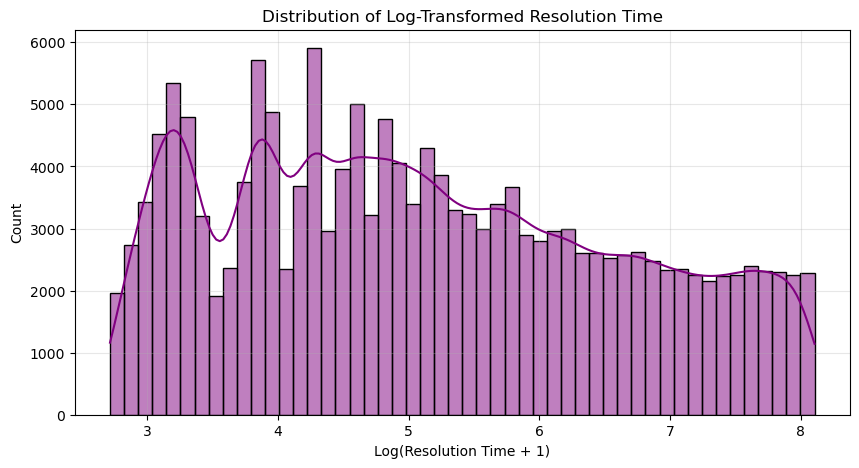

In [16]:
from pyspark.sql.functions import log1p

# --- Apply Log Transformation to Target Variable ---
# Using log1p (log(x+1)) to handle skewness and stabilize variance
print("Applying log1p transformation to resolution_time...")
df_model = df_model.withColumn("resolution_time", log1p(col("resolution_time")))

print("Target variable 'resolution_time' has been log-transformed.")
df_model.select("resolution_time").describe().show()

# Visualize the new distribution
print("Plotting distribution of log-transformed resolution time...")
plt.figure(figsize=(10, 5))
sns.histplot(df_model.select("resolution_time").toPandas()['resolution_time'], bins=50, kde=True, color='purple')
plt.title('Distribution of Log-Transformed Resolution Time')
plt.xlabel('Log(Resolution Time + 1)')
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
# Encode categorical variables using StringIndexer
indexers = [
    StringIndexer(inputCol=col_name, outputCol=f"{col_name}_idx", handleInvalid="keep")
    for col_name in categorical_cols
]

# Create feature vector
indexed_cols = [f"{col_name}_idx" for col_name in categorical_cols]
all_feature_cols = feature_cols + indexed_cols

assembler = VectorAssembler(
    inputCols=all_feature_cols,
    outputCol="features",
    handleInvalid="skip"
)

print(f"Total features for model: {len(all_feature_cols)}")
print("Feature columns:", all_feature_cols)

Total features for model: 17
Feature columns: ['coords', 'timestamp', 'state', 'count_reopen', 'last_activity', 'comment_len', 'lon', 'lat', 'pm25_avg', 'pm10_avg', 'dust_avg', 'rainfall_mm', 'has_rain', 'dept_count', 'organization_idx', 'type_clean_idx', 'district_idx']


## 5. Train/Test Split

In [18]:
# Split data 80/20
train_df, test_df = df_model.randomSplit([0.8, 0.2], seed=42)

print(f"Training set: {train_df.count()} rows")
print(f"Test set: {test_df.count()} rows")

Training set: 128474 rows
Test set: 32302 rows


## 6. Build Models (Linear Regression & XGBoost)

In [19]:
# --- 1. Linear Regression (Baseline) ---

# --- 2. XGBoost Regressor ---
xgb = SparkXGBRegressor(
    features_col="features",
    label_col="resolution_time",
    prediction_col="prediction",
    num_workers=2,
    max_depth=8,             
    n_estimators=300,         
    learning_rate=0.05,       
    subsample=0.8,            
    colsample_bytree=0.8,     
    min_child_weight=3,       
    objective="reg:squarederror",
    random_state=42
)

# Create pipelines
pipeline_xgb = Pipeline(stages=indexers + [assembler, xgb])
pipelines = [ ("XGBoost", pipeline_xgb)]

print(f"Models defined: {[p[0] for p in pipelines]}")

Models defined: ['XGBoost']


In [20]:
models = {}
predictions = {}

for name, pipeline in pipelines:
    print(f"\nTraining {name}...")
    try:
        model = pipeline.fit(train_df)
        models[name] = model
        
        print(f"Predicting with {name}...")
        pred = model.transform(test_df)
        predictions[name] = pred
    except Exception as e:
        print(f"Error training {name}: {e}")
    
print("\nTraining and Prediction complete!")


Training XGBoost...


2025-12-06 19:20:04,561 INFO XGBoost-PySpark: _fit Running xgboost-3.1.2 on 2 workers with
	booster params: {'objective': 'reg:squarederror', 'colsample_bytree': 0.8, 'device': 'cpu', 'learning_rate': 0.05, 'max_depth': 8, 'min_child_weight': 3, 'random_state': 42, 'subsample': 0.8, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 300}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
2025-12-06 19:20:34,294 INFO XGBoost-PySpark: _fit Finished xgboost training!


Predicting with XGBoost...

Training and Prediction complete!


In [21]:
evaluators = {
    "RMSE": RegressionEvaluator(labelCol="resolution_time", predictionCol="prediction", metricName="rmse"),
    "MAE": RegressionEvaluator(labelCol="resolution_time", predictionCol="prediction", metricName="mae"),
    "R2": RegressionEvaluator(labelCol="resolution_time", predictionCol="prediction", metricName="r2")
}

results = {}

for name, pred in predictions.items():
    print(f"\n--- {name} Evaluation ---")
    metrics = {}
    for metric_name, evaluator in evaluators.items():
        val = evaluator.evaluate(pred)
        metrics[metric_name] = val
        print(f"{metric_name}: {val:.4f}")
    results[name] = metrics


--- XGBoost Evaluation ---
RMSE: 1.2587
MAE: 1.0335
R2: 0.2720


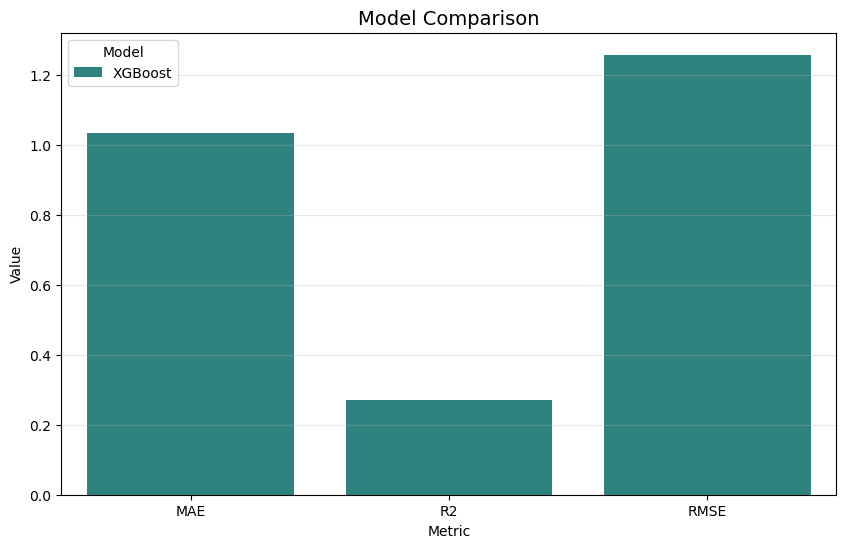

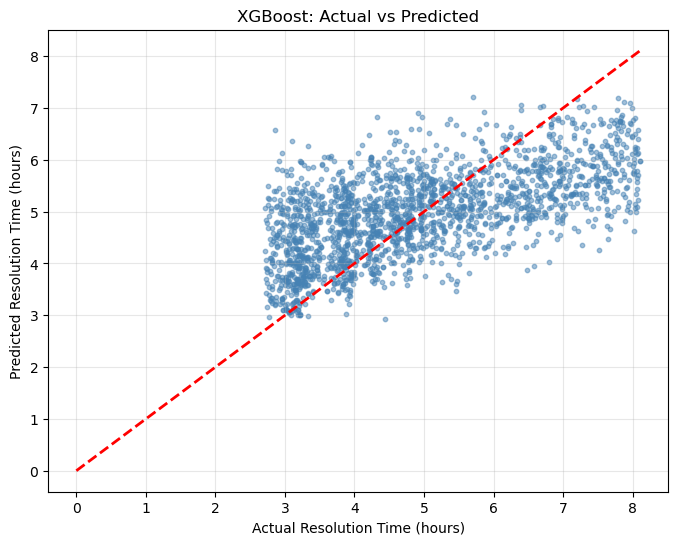

In [22]:
# Plot Model Comparison
if results:
    metrics_df = pd.DataFrame(results).T
    metrics_df = metrics_df.reset_index().melt(id_vars="index", var_name="Metric", value_name="Value")

    plt.figure(figsize=(10, 6))
    sns.barplot(data=metrics_df, x="Metric", y="Value", hue="index", palette="viridis")
    plt.title("Model Comparison", fontsize=14)
    plt.ylabel("Value")
    plt.xlabel("Metric")
    plt.grid(True, alpha=0.3, axis='y')
    plt.legend(title="Model")
    plt.show()

# Plot Actual vs Predicted (Sample)
for name, pred in predictions.items():
    pred_pd = pred.select("resolution_time", "prediction").limit(2000).toPandas()
    
    plt.figure(figsize=(8, 6))
    plt.scatter(pred_pd['resolution_time'], pred_pd['prediction'], alpha=0.5, s=10, c='steelblue')
    max_val = max(pred_pd['resolution_time'].max(), pred_pd['prediction'].max())
    plt.plot([0, max_val], [0, max_val], 'r--', lw=2)
    plt.xlabel('Actual Resolution Time (hours)')
    plt.ylabel('Predicted Resolution Time (hours)')
    plt.title(f'{name}: Actual vs Predicted')
    plt.grid(True, alpha=0.3)
    plt.show()

In [ ]:
# Save the XGBoost model
model_path = "../../models/xgboost_spark_model"
print(f"Saving XGBoost model to {model_path}...")
models['XGBoost'].write().overwrite().save(model_path)
print("Model saved successfully!")

In [ ]:
# # Stop Spark session
# spark.stop()
# print("Spark session stopped.")